In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

In [2]:
file_path = "wdbc.data"

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Load .data file
df = pd.read_csv(
    file_path,
    header=None,
    names=columns
)

print("Dataset loaded successfully")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully
Shape: (569, 32)

First 5 rows:
         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

In [3]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Diagnosis"].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  peri

In [4]:
df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print("\nEncoded Classes:")
print(df["Diagnosis"].value_counts())


Encoded Classes:
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


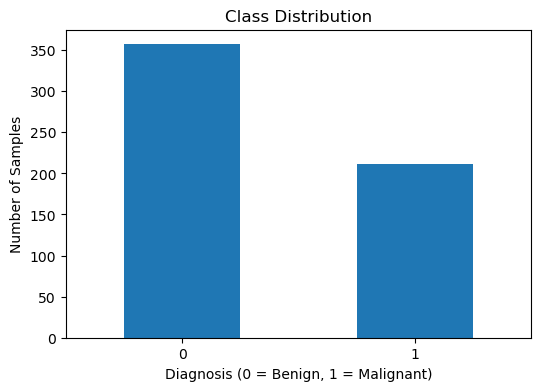

In [32]:
plt.figure(figsize=(6, 4))

y.value_counts().sort_index().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

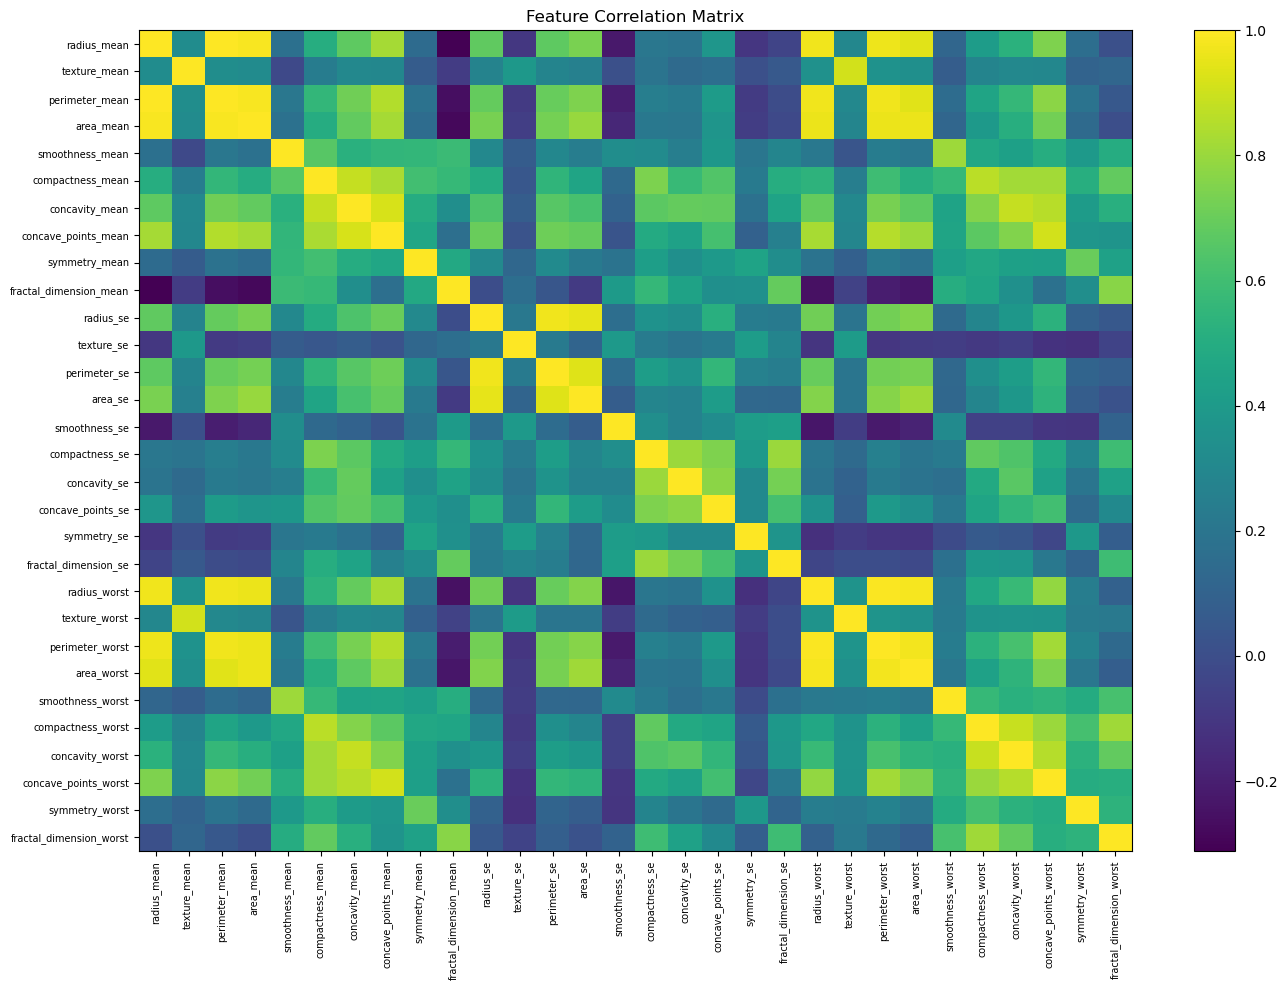

In [7]:
plt.figure(figsize=(14, 10))

correlation = X.corr()

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(X.columns)),
    X.columns,
    fontsize=7
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [10]:
dt = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [11]:
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1",
    return_train_score=False,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Decision Tree CV F1 Score:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Decision Tree CV F1 Score:
0.9163028549720931


In [12]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_results_table = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

dt_results_table.columns = [
    "Criterion",
    "Max Depth",
    "Min Samples Split",
    "Min Samples Leaf",
    "Avg CV F1 Score",
    "Std F1 Score"
]

dt_results_table["Avg CV F1 Score"] *= 100

print("\nDecision Tree Hyperparameter Evaluation:")
print(
    dt_results_table.sort_values(
        by="Avg CV F1 Score",
        ascending=False
    ).head(10)
)


Decision Tree Hyperparameter Evaluation:
    Criterion Max Depth  Min Samples Split  Min Samples Leaf  Avg CV F1 Score  \
93    entropy         4                  2                 2        91.630285   
94    entropy         4                  5                 2        91.630285   
90    entropy         4                  2                 1        91.447875   
95    entropy         4                 10                 2        91.419101   
104   entropy         5                 10                 2        91.212720   
91    entropy         4                  5                 1        91.077701   
122   entropy         8                 10                 2        90.941083   
140   entropy      None                 10                 2        90.941083   
131   entropy        10                 10                 2        90.941083   
113   entropy         6                 10                 2        90.941083   

     Std F1 Score  
93       0.034097  
94       0.034097  
90    

In [13]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:, 1]

In [14]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print("\nDecision Tree Performance")
print("--------------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Benign", "Malignant"]
))


Decision Tree Performance
--------------------------------
Accuracy : 0.9298245614035088
Precision: 1.0
Recall   : 0.8095238095238095
F1 Score : 0.8947368421052632
ROC-AUC  : 0.9563492063492064

Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95        72
   Malignant       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114



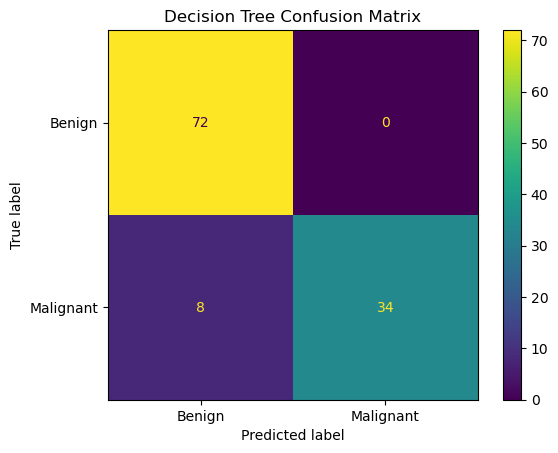

In [15]:
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [16]:
rf = RandomForestClassifier(
    random_state=42
)

rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 8, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

In [17]:
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    return_train_score=False,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}

Best Random Forest CV F1 Score:
0.9617018240249908


In [18]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_results_table = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_bootstrap",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

rf_results_table.columns = [
    "N Estimators",
    "Max Depth",
    "Max Features",
    "Bootstrap",
    "Avg CV F1 Score",
    "Std F1 Score"
]

rf_results_table["Avg CV F1 Score"] *= 100

print("\nRandom Forest Hyperparameter Evaluation:")
print(
    rf_results_table.sort_values(
        by="Avg CV F1 Score",
        ascending=False
    ).head(10)
)


Random Forest Hyperparameter Evaluation:
    N Estimators Max Depth Max Features  Bootstrap  Avg CV F1 Score  \
48            50        10         sqrt      False        96.170182   
47           150         8         log2      False        96.154013   
54            50      None         sqrt      False        95.888609   
53           150        10         log2      False        95.873064   
59           150      None         log2      False        95.873064   
52           100        10         log2      False        95.846853   
44           150         8         sqrt      False        95.845302   
51            50        10         log2      False        95.837414   
57            50      None         log2      False        95.837414   
38           150         5         sqrt      False        95.801624   

    Std F1 Score  
48      0.014626  
47      0.011994  
54      0.010564  
53      0.014523  
59      0.014523  
52      0.023854  
44      0.011595  
51      0.014965  
57   

In [19]:
best_rf = rf_grid.best_estimator_

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

In [20]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("\nRandom Forest Performance")
print("--------------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Benign", "Malignant"]
))


Random Forest Performance
--------------------------------
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95
ROC-AUC  : 0.9950396825396826

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



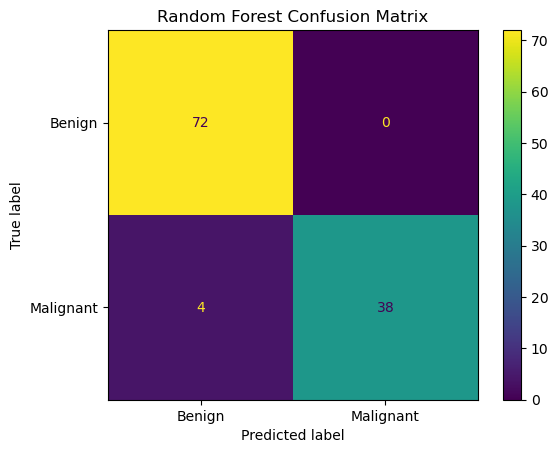

In [21]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [22]:
dt_fold_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_fold_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Fold 1": [
        dt_fold_scores[0],
        rf_fold_scores[0]
    ],
    "Fold 2": [
        dt_fold_scores[1],
        rf_fold_scores[1]
    ],
    "Fold 3": [
        dt_fold_scores[2],
        rf_fold_scores[2]
    ],
    "Fold 4": [
        dt_fold_scores[3],
        rf_fold_scores[3]
    ],
    "Fold 5": [
        dt_fold_scores[4],
        rf_fold_scores[4]
    ],
    "Average": [
        dt_fold_scores.mean(),
        rf_fold_scores.mean()
    ]
})

# Convert to percentage
for column in cv_comparison.columns[1:]:
    cv_comparison[column] *= 100

print("\n5-Fold Cross-Validation Accuracy Comparison:")
print(cv_comparison)


5-Fold Cross-Validation Accuracy Comparison:
           Model     Fold 1     Fold 2     Fold 3     Fold 4     Fold 5  \
0  Decision Tree  93.406593  95.604396  90.109890  95.604396  95.604396   
1  Random Forest  96.703297  98.901099  96.703297  95.604396  97.802198   

     Average  
0  94.065934  
1  97.142857  


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        dt_auc,
        rf_auc
    ]
})

print("\nFinal Model Comparison:")
print(comparison)


Final Model Comparison:
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Decision Tree  0.929825        1.0  0.809524  0.894737  0.956349
1  Random Forest  0.964912        1.0  0.904762  0.950000  0.995040


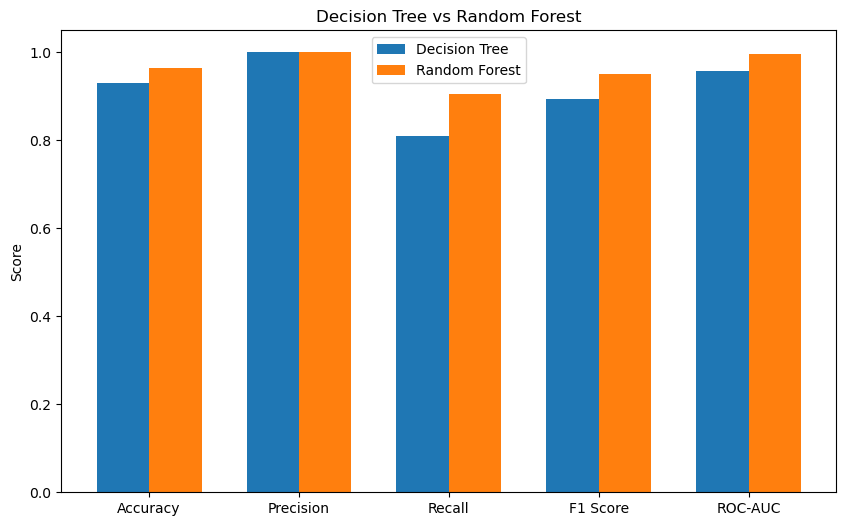

In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    comparison.iloc[0][metrics],
    width,
    label="Decision Tree"
)

plt.bar(
    x + width / 2,
    comparison.iloc[1][metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Decision Tree vs Random Forest")
plt.ylim(0, 1.05)
plt.legend()

plt.show()

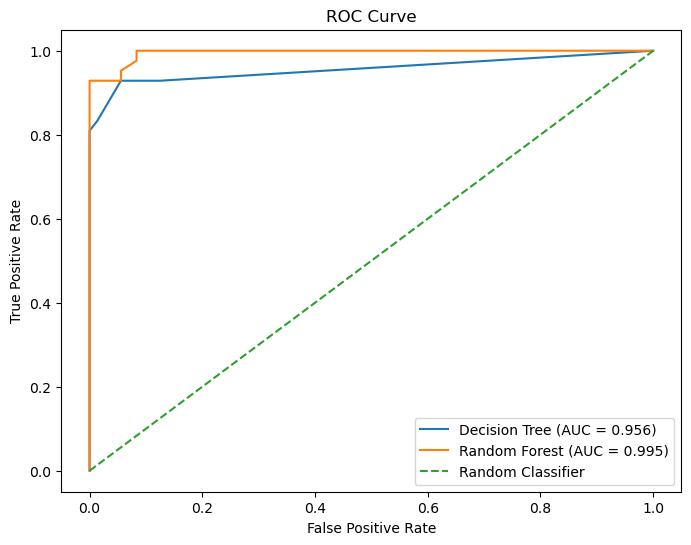

In [25]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [26]:
dt_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nDecision Tree Feature Importance:")
print(dt_importance.head(10))


Decision Tree Feature Importance:
perimeter_worst         0.661085
concave_points_worst    0.112664
concave_points_mean     0.085062
texture_worst           0.070786
area_se                 0.048619
compactness_se          0.017078
concavity_worst         0.004705
compactness_mean        0.000000
symmetry_mean           0.000000
smoothness_mean         0.000000
dtype: float64


In [27]:
rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(rf_importance.head(10))


Random Forest Feature Importance:
concave_points_worst    0.130944
area_worst              0.099966
perimeter_worst         0.092238
concave_points_mean     0.086401
perimeter_mean          0.084090
radius_worst            0.076337
area_mean               0.065008
concavity_worst         0.049736
concavity_mean          0.047543
radius_mean             0.043195
dtype: float64


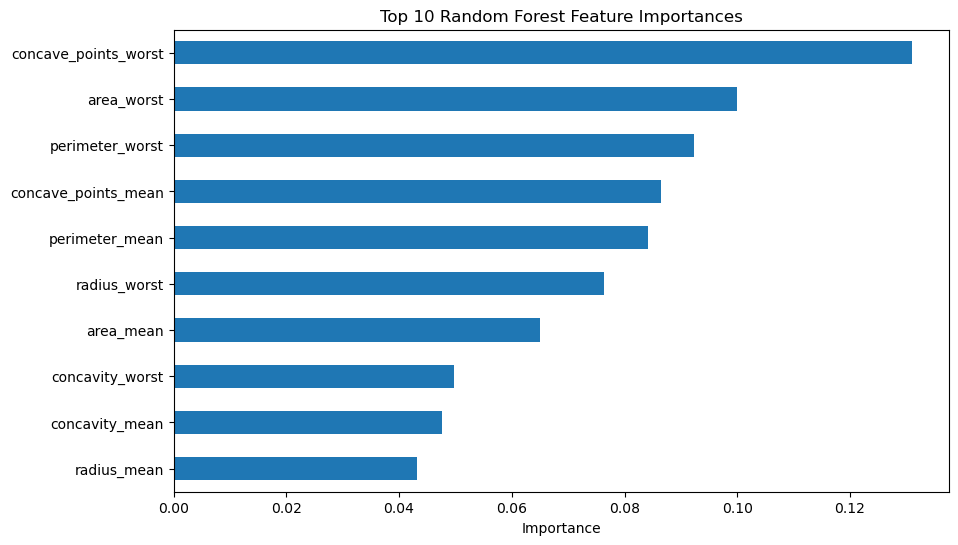

In [28]:
plt.figure(figsize=(10, 6))

rf_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")

plt.show()

In [29]:
print("\n==============================")
print("BEST HYPERPARAMETERS")
print("==============================")

print("\nDecision Tree:")
for key, value in dt_grid.best_params_.items():
    print(key, "=", value)

print("\nRandom Forest:")
for key, value in rf_grid.best_params_.items():
    print(key, "=", value)


BEST HYPERPARAMETERS

Decision Tree:
criterion = entropy
max_depth = 4
min_samples_leaf = 2
min_samples_split = 2

Random Forest:
bootstrap = False
max_depth = 10
max_features = sqrt
n_estimators = 50


In [30]:
print("\n==============================================")
print("FINAL PERFORMANCE COMPARISON")
print("==============================================")

print(f"{'Metric':<15} {'Decision Tree':<20} {'Random Forest':<20}")
print("-" * 55)

print(f"{'Accuracy':<15} {dt_accuracy:<20.4f} {rf_accuracy:<20.4f}")
print(f"{'Precision':<15} {dt_precision:<20.4f} {rf_precision:<20.4f}")
print(f"{'Recall':<15} {dt_recall:<20.4f} {rf_recall:<20.4f}")
print(f"{'F1 Score':<15} {dt_f1:<20.4f} {rf_f1:<20.4f}")
print(f"{'ROC-AUC':<15} {dt_auc:<20.4f} {rf_auc:<20.4f}")


FINAL PERFORMANCE COMPARISON
Metric          Decision Tree        Random Forest       
-------------------------------------------------------
Accuracy        0.9298               0.9649              
Precision       1.0000               1.0000              
Recall          0.8095               0.9048              
F1 Score        0.8947               0.9500              
ROC-AUC         0.9563               0.9950              
